In [1]:
import sys
sys.path.append("..")

from IPython.display import Image, display
from langgraph.graph import END, StateGraph

from catchup.rag.state import AgentState
from catchup.rag.conditional_edges import route_after_supervisor

async def _noop(*args, **kwargs):
    return {}

## Main Graph

`supervisor` → 5개 파이프라인으로 라우팅

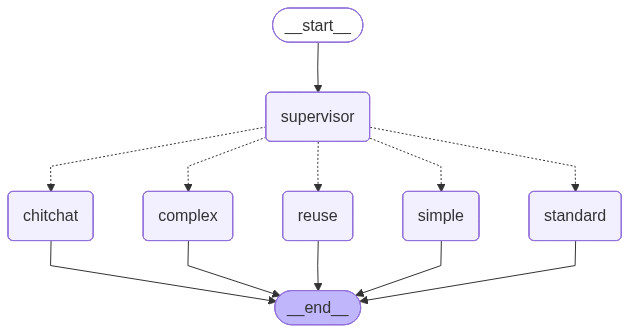

In [2]:
g = StateGraph(AgentState)
for name in ["supervisor", "chitchat", "reuse", "simple", "standard", "complex"]:
    g.add_node(name, _noop)

g.set_entry_point("supervisor")
g.add_conditional_edges(
    "supervisor",
    route_after_supervisor,
    {
        "chitchat": "chitchat",
        "reuse": "reuse",
        "simple": "simple",
        "standard": "standard",
        "complex": "complex",
    },
)
for name in ["chitchat", "reuse", "simple", "standard", "complex"]:
    g.add_edge(name, END)

main_graph = g.compile()
display(Image(main_graph.get_graph().draw_mermaid_png()))

## Reuse Subgraph

이전 턴의 `retrieved_docs`를 그대로 재사용해 답변 생성. 검색 없음.

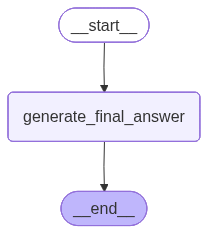

In [3]:
g = StateGraph(AgentState)
g.add_node("generate_final_answer", _noop)
g.set_entry_point("generate_final_answer")
g.add_edge("generate_final_answer", END)

reuse_graph = g.compile()
display(Image(reuse_graph.get_graph().draw_mermaid_png()))

## Simple Subgraph

단일 쿼리 직접 검색. LLM 2회 (supervisor + generate).

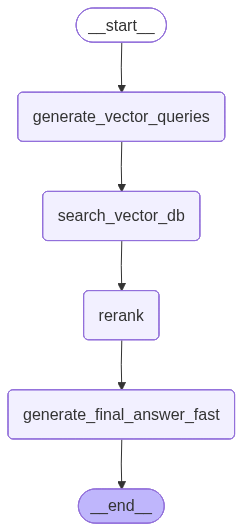

In [4]:
g = StateGraph(AgentState)
for name in ["generate_vector_queries", "search_vector_db", "rerank", "generate_final_answer_fast"]:
    g.add_node(name, _noop)

g.set_entry_point("generate_vector_queries")
g.add_edge("generate_vector_queries", "search_vector_db")
g.add_edge("search_vector_db", "rerank")
g.add_edge("rerank", "generate_final_answer_fast")
g.add_edge("generate_final_answer_fast", END)

simple_graph = g.compile()
display(Image(simple_graph.get_graph().draw_mermaid_png()))

## Standard ReAct Subgraph

SMALL 모델, max_iter=3. 검색 결과를 보고 추가 검색 여부를 agent가 직접 판단.

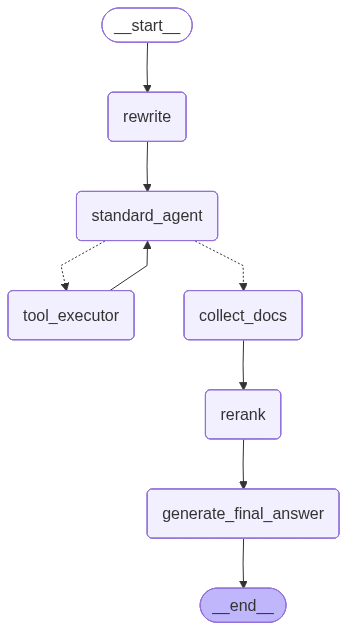

In [5]:
def _route_standard_agent(state: AgentState) -> str:
    pipeline_plan = state.get("pipeline_plan")
    max_iterations = pipeline_plan.max_iterations if pipeline_plan else 3
    if state.get("agent_iteration", 0) >= max_iterations:
        return "collect_docs"
    messages = state.get("messages", [])
    last = messages[-1] if messages else None
    if last and getattr(last, "tool_calls", None):
        return "tool_executor"
    return "collect_docs"


g = StateGraph(AgentState)
for name in ["rewrite", "standard_agent", "tool_executor", "collect_docs", "rerank", "generate_final_answer"]:
    g.add_node(name, _noop)

g.set_entry_point("rewrite")
g.add_edge("rewrite", "standard_agent")
g.add_conditional_edges(
    "standard_agent",
    _route_standard_agent,
    {"tool_executor": "tool_executor", "collect_docs": "collect_docs"},
)
g.add_edge("tool_executor", "standard_agent")
g.add_edge("collect_docs", "rerank")
g.add_edge("rerank", "generate_final_answer")
g.add_edge("generate_final_answer", END)

standard_graph = g.compile()
display(Image(standard_graph.get_graph().draw_mermaid_png()))

## Complex ReAct Subgraph

LARGE 모델, max_iter=7, Extended Thinking.
- Phase 1: `complex_planner` — 검색 전략 수립 (extended thinking)
- Phase 2: `complex_agent` ↔ `tool_executor` — Self-improving ReAct loop
- Phase 3: `gap_analysis` — 수집된 정보 충분성 평가 (extended thinking)
- Phase 4: `collect_docs` → `rerank` → `generate_final_answer`

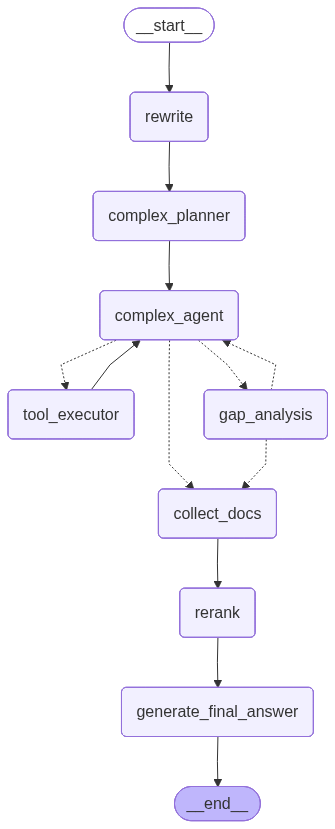

In [6]:
def _route_complex_agent(state: AgentState) -> str:
    pipeline_plan = state.get("pipeline_plan")
    max_iterations = pipeline_plan.max_iterations if pipeline_plan else 7
    if state.get("agent_iteration", 0) >= max_iterations:
        return "collect_docs"
    messages = state.get("messages", [])
    last = messages[-1] if messages else None
    if last and getattr(last, "tool_calls", None):
        return "tool_executor"
    return "gap_analysis"


def _route_gap_analysis(state: AgentState) -> str:
    pipeline_plan = state.get("pipeline_plan")
    max_iterations = pipeline_plan.max_iterations if pipeline_plan else 7
    agent_iteration = state.get("agent_iteration", 0)
    gap_analysis = state.get("gap_analysis")
    if gap_analysis is None or gap_analysis.is_sufficient or agent_iteration >= max_iterations:
        return "collect_docs"
    return "complex_agent"


g = StateGraph(AgentState)
for name in [
    "rewrite", "complex_planner", "complex_agent",
    "tool_executor", "gap_analysis",
    "collect_docs", "rerank", "generate_final_answer",
]:
    g.add_node(name, _noop)

g.set_entry_point("rewrite")
g.add_edge("rewrite", "complex_planner")
g.add_edge("complex_planner", "complex_agent")
g.add_conditional_edges(
    "complex_agent",
    _route_complex_agent,
    {"tool_executor": "tool_executor", "gap_analysis": "gap_analysis", "collect_docs": "collect_docs"},
)
g.add_edge("tool_executor", "complex_agent")
g.add_conditional_edges(
    "gap_analysis",
    _route_gap_analysis,
    {"complex_agent": "complex_agent", "collect_docs": "collect_docs"},
)
g.add_edge("collect_docs", "rerank")
g.add_edge("rerank", "generate_final_answer")
g.add_edge("generate_final_answer", END)

complex_graph = g.compile()
display(Image(complex_graph.get_graph().draw_mermaid_png()))